1. Baseline ( Logistic Regression)

In [17]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

from src.config import PROCESSED_DATA_DIR

features = pd.read_parquet(PROCESSED_DATA_DIR / "customer_features.parquet")
print(features.shape)
features.head()

(5878, 22)


,Customer ID,last_purchase_date,first_purchase_date,frequency,monetary_total,recency_days,tenure_days,monetary_avg,monetary_std,orders_recent,orders_prior,spend_recent,spend_prior,order_frequency_trend,spend_trend,n_distinct_products,country,has_returned,return_rate,log_frequency,log_monetary_total,is_churned
0,12346.0,2011-01-18 10:01:00,2009-12-14 08:34:00,12,77556.46,325,725,6463.038333,22271.229481,0.0,0.0,0.00,0.00,0.000000,0.000000,27,United Kingdom,True,0.294118,2.564949,11.258774,1
1,12347.0,2011-12-07 15:52:00,2010-10-31 14:20:00,8,5633.32,1,403,704.165000,427.421078,1.0,2.0,584.91,1018.77,0.333333,0.573571,126,Iceland,False,0.000000,2.197225,8.636632,0
2,12348.0,2011-09-25 13:13:00,2010-09-27 14:59:00,5,2019.40,74,437,403.880000,279.897118,0.0,1.0,0.00,367.00,0.000000,0.000000,25,Finland,False,0.000000,1.791759,7.611051,0
3,12349.0,2011-11-21 09:51:00,2010-04-29 13:20:00,4,4428.69,18,588,1107.172500,667.017261,0.0,0.0,0.00,0.00,0.000000,0.000000,138,Italy,True,0.200000,1.609438,8.396085,0
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,309,309,334.400000,0.000000,0.0,0.0,0.00,0.00,0.000000,0.000000,17,Norway,False,0.000000,0.693147,5.815324,1


In [18]:
features["country"].value_counts()

country
United Kingdom          5350
Germany                  106
France                    95
Spain                     38
Belgium                   28
Portugal                  24
Switzerland               22
Netherlands               22
Sweden                    19
Italy                     17
Finland                   14
Australia                 14
Norway                    13
Channel Islands           13
Austria                   11
Cyprus                    10
Japan                     10
Denmark                    9
USA                        9
Unspecified                6
Poland                     6
Greece                     5
Canada                     5
Israel                     4
United Arab Emirates       4
EIRE                       4
Bahrain                    2
RSA                        2
Brazil                     2
Korea                      2
Malta                      2
Iceland                    1
Thailand                   1
Saudi Arabia               1
Singap

In [19]:
features["is_churned"].value_counts(normalize=True)

is_churned
1    0.53998
0    0.46002
Name: proportion, dtype: float64

In [20]:
TOP_COUNTRIES = ["United Kingdom", "Germany", "France", "Spain", "Belgium"]

features["country_grouped"] = features["country"].where(
    features["country"].isin(TOP_COUNTRIES), other="Other"
)

features["country_grouped"].value_counts()

country_grouped
United Kingdom    5350
Other              261
Germany            106
France              95
Spain               38
Belgium             28
Name: count, dtype: int64

In [21]:
# Excluded: identifiers, raw dates, and anything that leaks the churn label definition
EXCLUDE_COLS = [
    "Customer ID", "last_purchase_date", "first_purchase_date",
    "country",          # replaced by country_grouped
    "recency_days",     # excluded: this IS the churn label definition — using it = leakage
    "is_churned",       # target, not a feature
]

model_df = features.drop(columns=EXCLUDE_COLS)

# one-hot encode country_grouped
model_df = pd.get_dummies(model_df, columns=["country_grouped"], drop_first=True)

print(model_df.shape)
model_df.columns.tolist()

(5878, 21)


['frequency',
 'monetary_total',
 'tenure_days',
 'monetary_avg',
 'monetary_std',
 'orders_recent',
 'orders_prior',
 'spend_recent',
 'spend_prior',
 'order_frequency_trend',
 'spend_trend',
 'n_distinct_products',
 'has_returned',
 'return_rate',
 'log_frequency',
 'log_monetary_total',
 'country_grouped_France',
 'country_grouped_Germany',
 'country_grouped_Other',
 'country_grouped_Spain',
 'country_grouped_United Kingdom']

In [22]:
model_df.dtypes

frequency                           int64
monetary_total                    float64
tenure_days                         int64
monetary_avg                      float64
monetary_std                      float64
orders_recent                     float64
orders_prior                      float64
spend_recent                      float64
spend_prior                       float64
order_frequency_trend             float64
spend_trend                       float64
n_distinct_products                 int64
has_returned                         bool
return_rate                       float64
log_frequency                     float64
log_monetary_total                float64
country_grouped_France               bool
country_grouped_Germany              bool
country_grouped_Other                bool
country_grouped_Spain                bool
country_grouped_United Kingdom       bool
dtype: object

In [23]:
from sklearn.model_selection import train_test_split

X = model_df
y = features["is_churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.1%}, Test churn rate: {y_test.mean():.1%}")

Train: (4702, 21), Test: (1176, 21)
Train churn rate: 54.0%, Test churn rate: 54.0%


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       541
           1       0.84      0.87      0.86       635

    accuracy                           0.84      1176
   macro avg       0.84      0.84      0.84      1176
weighted avg       0.84      0.84      0.84      1176


ROC-AUC: 0.904


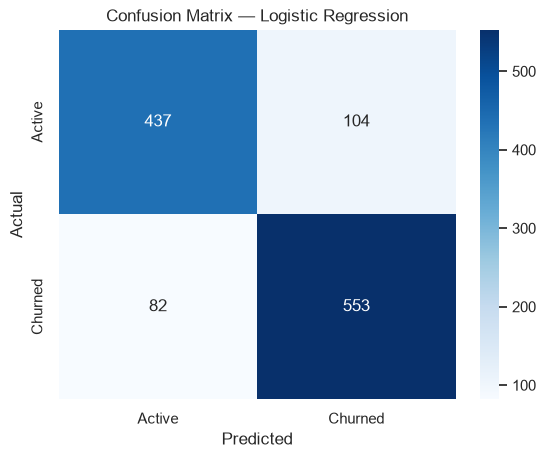

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"], yticklabels=["Active", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

In [35]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

coef_df

,feature,coefficient
14,log_frequency,-2.725515
2,tenure_days,1.970401
6,orders_prior,1.055035
5,orders_recent,-0.809338
9,order_frequency_trend,0.797888
4,monetary_std,-0.599595
3,monetary_avg,0.561442
11,n_distinct_products,-0.550200
7,spend_recent,-0.493290
0,frequency,0.487614


In [30]:
print(features["orders_recent"].sum(), features["orders_prior"].sum())

4095.0 4086.0


In [32]:
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       541
           1       0.84      0.87      0.86       635

    accuracy                           0.84      1176
   macro avg       0.84      0.84      0.84      1176
weighted avg       0.84      0.84      0.84      1176

ROC-AUC: 0.904


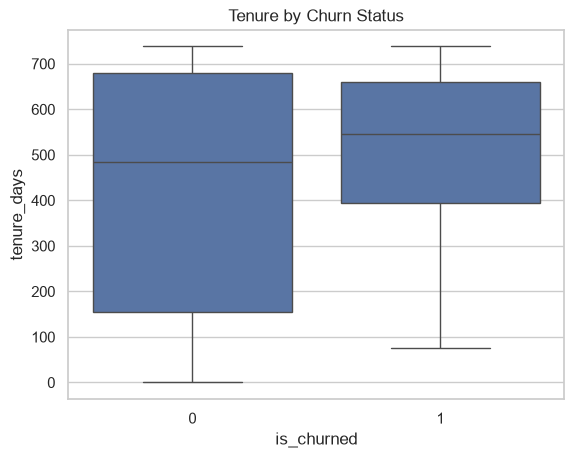

In [36]:
sns.boxplot(data=features, x="is_churned", y="tenure_days")
plt.title("Tenure by Churn Status")
plt.show()

**Training a Tree Based Model to compare on**


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # tree models don't need scaling

rf_pred = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_pred_proba):.3f}")

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       541
           1       0.84      0.85      0.84       635

    accuracy                           0.83      1176
   macro avg       0.83      0.83      0.83      1176
weighted avg       0.83      0.83      0.83      1176

ROC-AUC: 0.918


In [38]:
# if not installed: pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_pred_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_pred_proba):.3f}")

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       541
           1       0.86      0.86      0.86       635

    accuracy                           0.85      1176
   macro avg       0.85      0.85      0.85      1176
weighted avg       0.85      0.85      0.85      1176

ROC-AUC: 0.935


Comparison between two models

In [39]:
from sklearn.metrics import f1_score, recall_score, precision_score

results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    },
    {
        "model": "Random Forest",
        "roc_auc": roc_auc_score(y_test, rf_pred_proba),
        "precision": precision_score(y_test, rf_pred),
        "recall": recall_score(y_test, rf_pred),
        "f1": f1_score(y_test, rf_pred),
    },
    {
        "model": "XGBoost",
        "roc_auc": roc_auc_score(y_test, xgb_pred_proba),
        "precision": precision_score(y_test, xgb_pred),
        "recall": recall_score(y_test, xgb_pred),
        "f1": f1_score(y_test, xgb_pred),
    },
])

results

,model,roc_auc,precision,recall,f1
0,Logistic Regression,0.903943,0.841705,0.870866,0.856037
1,Random Forest,0.917738,0.836420,0.853543,0.844895
2,XGBoost,0.934777,0.857143,0.859843,0.858491


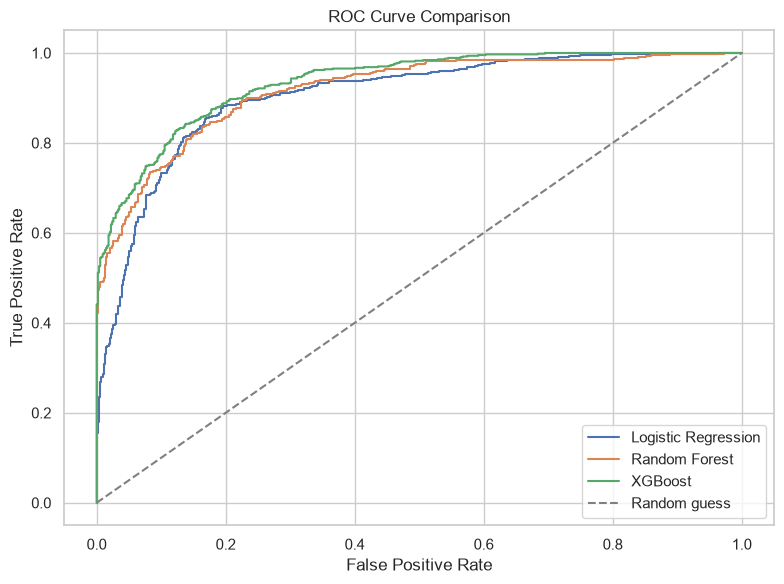

In [40]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, proba in [("Logistic Regression", y_pred_proba),
                     ("Random Forest", rf_pred_proba),
                     ("XGBoost", xgb_pred_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

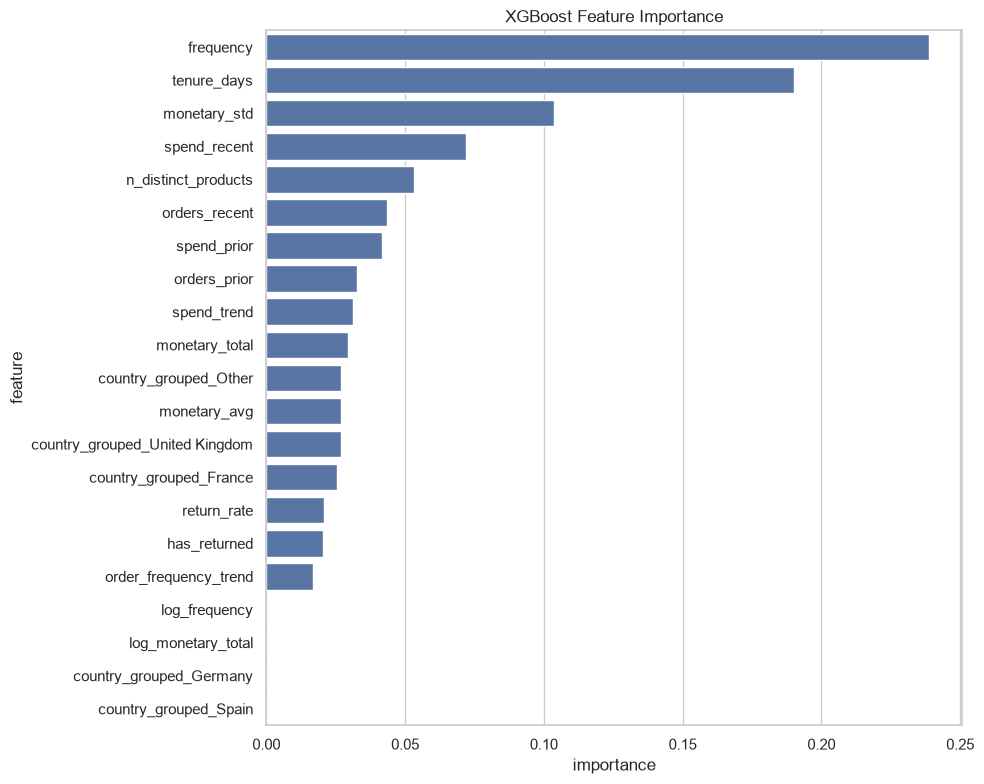

In [41]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

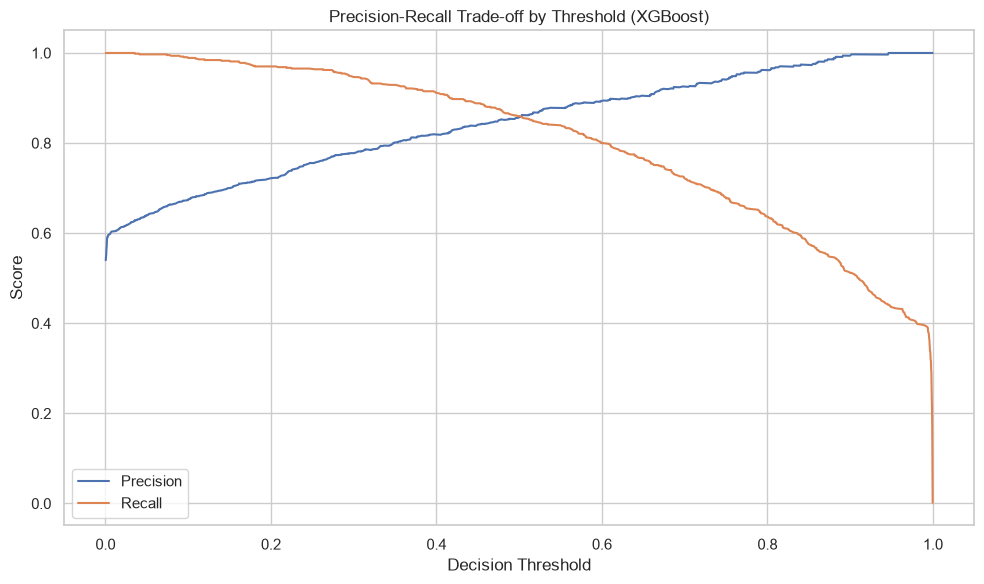

In [42]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off by Threshold (XGBoost)")
plt.legend()
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.90      0.73      0.81       541
           1       0.80      0.93      0.86       635

    accuracy                           0.84      1176
   macro avg       0.85      0.83      0.83      1176
weighted avg       0.85      0.84      0.84      1176



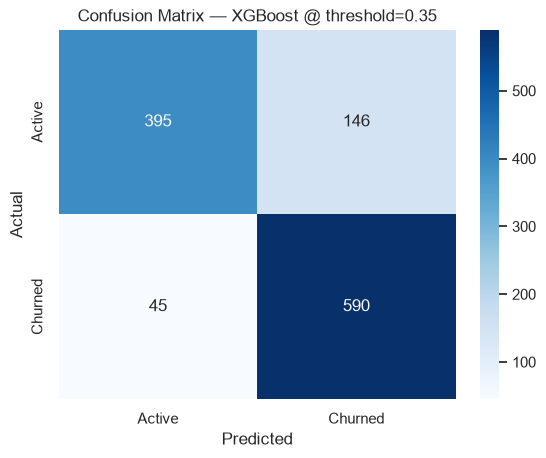

In [43]:
custom_threshold = 0.35

y_pred_custom = (xgb_pred_proba >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

cm_custom = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"], yticklabels=["Active", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — XGBoost @ threshold={custom_threshold}")
plt.show()

In [44]:
avg_order_value = features["monetary_avg"].mean()
print(f"Average order value across all customers: £{avg_order_value:.2f}")

Average order value across all customers: £391.73


In [45]:
from src.config import RETENTION_CAMPAIGN_COST_PER_CUSTOMER, RETENTION_CAMPAIGN_SUCCESS_RATE

TP, FP, FN, TN = 590, 146, 45, 395

customers_targeted = TP + FP  # everyone the model flags as at-risk, since that's who gets the campaign
customers_saved = TP * RETENTION_CAMPAIGN_SUCCESS_RATE  # successful retentions among true churners

revenue_recovered = customers_saved * avg_order_value
campaign_cost = customers_targeted * RETENTION_CAMPAIGN_COST_PER_CUSTOMER

net_value = revenue_recovered - campaign_cost

print(f"Customers targeted (TP + FP): {customers_targeted}")
print(f"Expected successful retentions (TP x success rate): {customers_saved:.1f}")
print(f"Revenue recovered: £{revenue_recovered:,.2f}")
print(f"Campaign cost: £{campaign_cost:,.2f}")
print(f"Net value: £{net_value:,.2f}")

Customers targeted (TP + FP): 736
Expected successful retentions (TP x success rate): 88.5
Revenue recovered: £34,667.80
Campaign cost: £2,208.00
Net value: £32,459.80


In [46]:
# Baseline: target ALL churned customers in the test set (no model, just blanket campaign)
total_churned = TP + FN
blanket_cost = (TP + FP + TN + FN) * RETENTION_CAMPAIGN_COST_PER_CUSTOMER  # campaign to literally everyone
blanket_saved = total_churned * RETENTION_CAMPAIGN_SUCCESS_RATE
blanket_revenue = blanket_saved * avg_order_value
blanket_net = blanket_revenue - blanket_cost

print(f"Blanket campaign (target everyone) net value: £{blanket_net:,.2f}")
print(f"Model-targeted campaign net value: £{net_value:,.2f}")
print(f"Improvement from using the model: £{net_value - blanket_net:,.2f}")

Blanket campaign (target everyone) net value: £33,783.95
Model-targeted campaign net value: £32,459.80
Improvement from using the model: £-1,324.15


In [47]:
for cost in [3, 10, 20, 30, 50]:
    campaign_cost_test = customers_targeted * cost
    net_value_test = revenue_recovered - campaign_cost_test
    
    blanket_cost_test = (TP + FP + TN + FN) * cost
    blanket_net_test = blanket_revenue - blanket_cost_test
    
    print(f"Cost=£{cost}: Model net=£{net_value_test:,.0f} | Blanket net=£{blanket_net_test:,.0f} | Model wins by £{net_value_test - blanket_net_test:,.0f}")

Cost=£3: Model net=£32,460 | Blanket net=£33,784 | Model wins by £-1,324
Cost=£10: Model net=£27,308 | Blanket net=£25,552 | Model wins by £1,756
Cost=£20: Model net=£19,948 | Blanket net=£13,792 | Model wins by £6,156
Cost=£30: Model net=£12,588 | Blanket net=£2,032 | Model wins by £10,556
Cost=£50: Model net=£-2,132 | Blanket net=£-21,488 | Model wins by £19,356


In [48]:
import numpy as np

costs = np.arange(1, 15, 0.5)
breakeven_results = []

for cost in costs:
    campaign_cost_test = customers_targeted * cost
    net_value_test = revenue_recovered - campaign_cost_test

    blanket_cost_test = (TP + FP + TN + FN) * cost
    blanket_net_test = blanket_revenue - blanket_cost_test

    breakeven_results.append({
        "cost": cost,
        "model_advantage": net_value_test - blanket_net_test
    })

breakeven_df = pd.DataFrame(breakeven_results)
breakeven_df[breakeven_df["model_advantage"] > 0].head(3)

,cost,model_advantage
11,6.5,215.84587
12,7.0,435.84587
13,7.5,655.84587


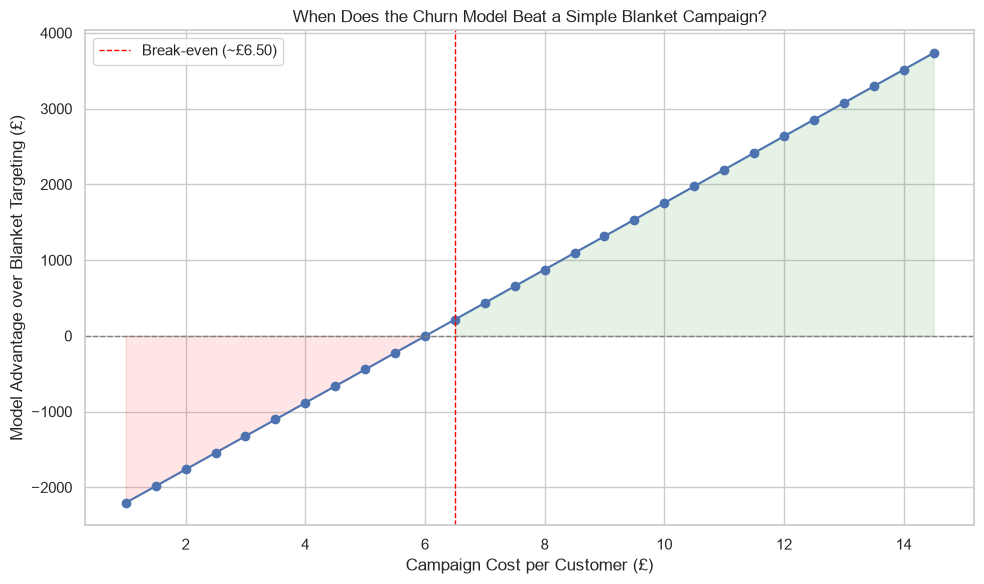

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(breakeven_df["cost"], breakeven_df["model_advantage"], marker="o")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(6.5, color="red", linestyle="--", linewidth=1, label="Break-even (~£6.50)")
plt.fill_between(breakeven_df["cost"], breakeven_df["model_advantage"], 0,
                  where=(breakeven_df["model_advantage"] >= 0), color="green", alpha=0.1)
plt.fill_between(breakeven_df["cost"], breakeven_df["model_advantage"], 0,
                  where=(breakeven_df["model_advantage"] < 0), color="red", alpha=0.1)
plt.xlabel("Campaign Cost per Customer (£)")
plt.ylabel("Model Advantage over Blanket Targeting (£)")
plt.title("When Does the Churn Model Beat a Simple Blanket Campaign?")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/model_roi_breakeven.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(xgb, MODELS_DIR / "churn_model.pkl")
joblib.dump(list(X.columns), MODELS_DIR / "feature_columns.pkl")

print("Model and feature columns saved.")

Model and feature columns saved.


In [51]:
features["churn_probability"] = xgb.predict_proba(model_df)[:, 1]
features["predicted_churn"] = (features["churn_probability"] >= 0.35).astype(int)

features.to_parquet("../data/processed/customer_predictions.parquet", index=False)
print("Predictions saved.")

Predictions saved.
